# Calibration

Trying out new calibration method.
Using xy files generated from mzXML sum spectra (VisuCon samples), containing
data for IgG, IgA and IgM.

## Data preparation


In [38]:
from pathlib import Path
import re
import sys

import matplotlib.pyplot as plt
from matplotlib.figure import Figure
import numpy as np
import pandas as pd

# Make paths independent of whether Jupyter starts in the repository root
# or in the tests directory containing this notebook.
project_root = Path.cwd()
if not (project_root / "sweet_suite").is_dir():
    project_root = project_root.parent
if not (project_root / "sweet_suite").is_dir():
    raise FileNotFoundError("Could not locate the SweetSuite project root")
sys.path.insert(0, str(project_root))

from sweet_suite.mass_spectrometry.mass_spectrum import MassSpectrum

In [39]:
xy_folder = project_root / "tests" / "xy_uncalibrated_sumspectra"

analytes_ref_path = project_root / "tests" / "analytes_ref.xlsx"
analytes_ref = pd.read_excel(analytes_ref_path)
ref_calibrants = analytes_ref[analytes_ref["calibrant"]]

BACKGROUND_MASS_WINDOW = 10.0
CALIBRATION_MASS_WINDOW = 0.2
CALIBRANT_SN_CUTOFF = 100

In [40]:
SUM_SPECTRUM_PATTERN = re.compile(
    r"^SumSpectrum_(?P<time>[^_]+)_(?P<time_window>[^_]+)_(?P<file_raw>.+)$"
)

def parse_sum_spectrum_path(path):
    match = SUM_SPECTRUM_PATTERN.fullmatch(Path(path).stem)
    return (
        float(match["time"]),
        float(match["time_window"]),
        match["file_raw"],
    )

def read_xy_file(path):
    return np.loadtxt(path)

In [41]:
# Check number of sum spectra created per mzXML.
xy_paths_by_file = {}
for path in xy_folder.glob("*.xy"):
    time, time_window, file_raw = parse_sum_spectrum_path(path)
    xy_paths_by_file.setdefault(file_raw, []).append(
        (time, time_window, path)
    )

for xy_paths in xy_paths_by_file.values():
    xy_paths.sort(key=lambda item: (item[0], item[1]))

group_summary = pd.DataFrame(
    {
        "raw_file": file_raw,
        "plate_position": file_raw.rsplit("-", 1)[-1],
        "sum_spectra": len(xy_paths),
    }
    for file_raw, xy_paths in sorted(xy_paths_by_file.items())
)

group_summary

,raw_file,plate_position,sum_spectra
0,aligned_2026GLY00034-PL01_B09,PL01_B09,12
1,aligned_2026GLY00034-PL01_D06,PL01_D06,12
2,aligned_2026GLY00034-PL01_E01,PL01_E01,12
3,aligned_2026GLY00034-PL01_G12,PL01_G12,12
4,aligned_2026GLY00034-PL02_B07,PL02_B07,12
5,aligned_2026GLY00034-PL02_E01,PL02_E01,12
6,aligned_2026GLY00034-PL02_F09,PL02_F09,12
7,aligned_2026GLY00034-PL02_G04,PL02_G04,12
8,aligned_2026GLY00034-PL02_H11,PL02_H11,12


We can now replicate part of the batch process.

In [42]:
mass_spectra = {}

# Loop over raw file (indicating mzXML file) and corresponding xy files
for file_raw, xy_paths in sorted(xy_paths_by_file.items()):

    file_mass_spectra = []  # To collect mass spectrum instances for this mzXML

    # Loop over xy sum spectra
    for time, time_window, path in xy_paths:

        # Select calibrants in this retention time range
        calibrants_df = (
            ref_calibrants[
                (ref_calibrants["time"] == time)
                & (ref_calibrants["time_window"] == time_window)
            ]
            .assign(
                charge=lambda frame: (
                    frame["peak"].str.split("_").str[1].astype(int)
                )
            )
            [["mz", "charge", "mz_window"]]
        )

        # Create a MassSpectrum instance and add to list.
        file_mass_spectra.append(
            MassSpectrum(
                name=path.stem,
                file_raw=file_raw,
                data_uncalibrated=read_xy_file(path),
                background_mass_window=BACKGROUND_MASS_WINDOW,
                calibration_mass_window=CALIBRATION_MASS_WINDOW,
                calibrants_df=calibrants_df,
                time=time,
                time_window=time_window,
            )
        )

    # Add list of Mass Spectra for this mzXML file to the dictionary.
    mass_spectra[file_raw] = file_mass_spectra


# Inspect number of spectra per mzXML as a sanity check.
{file_raw: len(spectra) for file_raw, spectra in mass_spectra.items()}

{'aligned_2026GLY00034-PL01_B09': 12,
 'aligned_2026GLY00034-PL01_D06': 12,
 'aligned_2026GLY00034-PL01_E01': 12,
 'aligned_2026GLY00034-PL01_G12': 12,
 'aligned_2026GLY00034-PL02_B07': 12,
 'aligned_2026GLY00034-PL02_E01': 12,
 'aligned_2026GLY00034-PL02_F09': 12,
 'aligned_2026GLY00034-PL02_G04': 12,
 'aligned_2026GLY00034-PL02_H11': 12}

In [43]:
# Collect all calibrants per mzXML file.
calibrants_dict = {}

for file_raw, file_mass_spectra in mass_spectra.items():
    
    file_calibrants = []

    for ms in file_mass_spectra:
        for cal in ms.calibrants:
            if cal.signal_to_noise > CALIBRANT_SN_CUTOFF:
                file_calibrants.append(
                    {
                        "time": cal.time,
                        "signal_to_noise": cal.signal_to_noise,
                        "mz_exact": cal.mz_exact,
                        "mz_observed": cal.mz_observed,
                    }
                )

    calibrants_dict[file_raw] = file_calibrants

pd.DataFrame(
    {"raw_file": file_raw, "calibrants": len(values)}
    for file_raw, values in calibrants_dict.items()
)

,raw_file,calibrants
0,aligned_2026GLY00034-PL01_B09,13
1,aligned_2026GLY00034-PL01_D06,25
2,aligned_2026GLY00034-PL01_E01,31
3,aligned_2026GLY00034-PL01_G12,26
4,aligned_2026GLY00034-PL02_B07,26
5,aligned_2026GLY00034-PL02_E01,34
6,aligned_2026GLY00034-PL02_F09,25
7,aligned_2026GLY00034-PL02_G04,28
8,aligned_2026GLY00034-PL02_H11,26


## Calibration methods
We now have a dictionary called `calibrants_dict`, which has a list
of calibrants for each mzXML file (this is the `calibrants` list in 
`batch_worker.py` line 790).

### Existing calibration model
We'll start by fitting the existing m/z-only calibration model, using a
quadratic fit, but with a small change. Instead of fitting exact m/z
values as a function of observed m/z, we'll fit the required m/z correction
$\Delta m/z = m/z_\text{exact} - m/z_\text{observed}$ as a function
of observed m/z:

$$ \Delta m/z = \beta_0 + \beta_1 \times m/z_\text{observed} + \beta_2 \times (m/z_\text{observed})^2 $$

The existing m/z values in the spectrum are then calibrated by adding the predicted correction:

$$ m/z_\text{calibrated} = m/z_\text{existing} + (\Delta m/z)_\text{correction}$$

This has a simple interpretation: the model predicts how much the observed m/z value should be shifted.

In [44]:
def calibration_fit_quadratic(calibrants: list[dict]) -> np.ndarray:
    """Fit a quadratic m/z calibration model.
    
    The model predicts the required m/z correction:

        mz_exact - mz_observed

    as a quadratic function of the observed m/z.

    Returns a NumPy array containing the polynomial coefficients in descending
    order: [quadratic, linear, intercept]
    """
    mz_observed = np.array(
        [
            calibrant["mz_observed"] 
            for calibrant in calibrants
        ],
        dtype=float
    )

    mz_delta = np.array(
        [
            calibrant["mz_exact"] - calibrant["mz_observed"]
            for calibrant in calibrants
        ],
        dtype=float
    )

    fit = np.polyfit(
        x=mz_observed,
        y=mz_delta,
        deg=2
    )

    return fit

In [45]:
def plot_calibration_fit_quadratic(
    calibrants: list[dict],
    fit: np.ndarray,
    raw_file: str
) -> Figure:
    mz_observed = np.array(
        [
            calibrant["mz_observed"]
            for calibrant in calibrants
        ],
        dtype=float
    )

    mz_delta = np.array(
        [
            calibrant["mz_exact"] - calibrant["mz_observed"]
            for calibrant in calibrants
        ]
    )

    # Get retention times to color the points by
    time = np.array(
        [
            calibrant["time"]
            for calibrant in calibrants
        ],
        dtype=float
    )

    # Create evenly spaced m/z values for drawing smooth fitted curve
    mz_plot = np.linspace(
        mz_observed.min(),
        mz_observed.max(),
        500
    )

    # Apply the fit to the specified m/z values
    delta_fitted = np.polyval(fit, mz_plot)

    # Make figure
    figure, axis = plt.subplots()
    scatter = axis.scatter(
        mz_observed,
        mz_delta,
        c=time,
        cmap="turbo",
        s=45,
        edgecolor="black",
        linewidths=0.4
    )
    axis.plot(
        mz_plot,
        delta_fitted,
        label="Quadratic fit"
    )
    axis.axhline(0, linewidth=1, linestyle="--")
    axis.set_xlabel(r"Observed $m/z$")
    axis.set_ylabel(r"Required correction $\Delta m/z$")
    axis.set_title(f"Quadratic m/z calibration fit\n{raw_file}")
    axis.legend()
    colorbar = figure.colorbar(scatter, ax=axis)
    colorbar.set_label("Retention time")
    figure.tight_layout()

    return figure

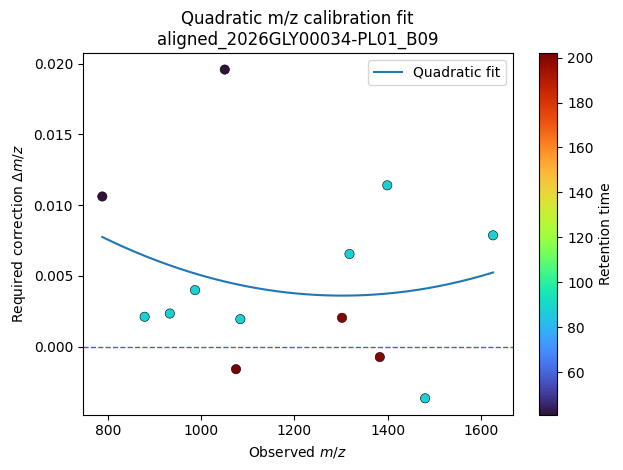

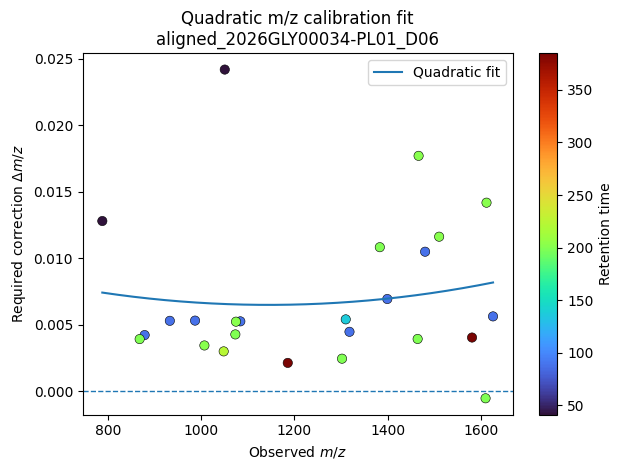

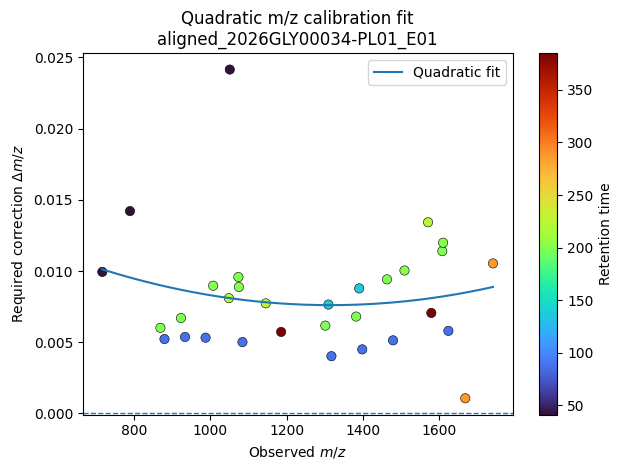

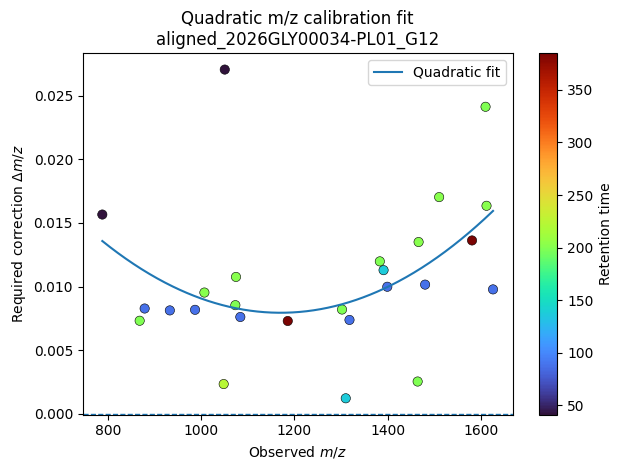

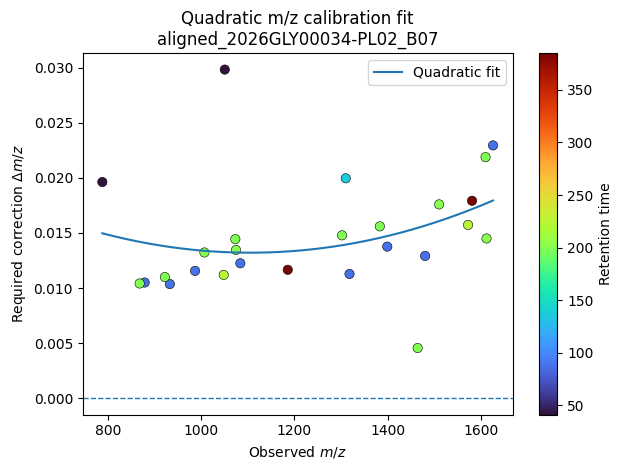

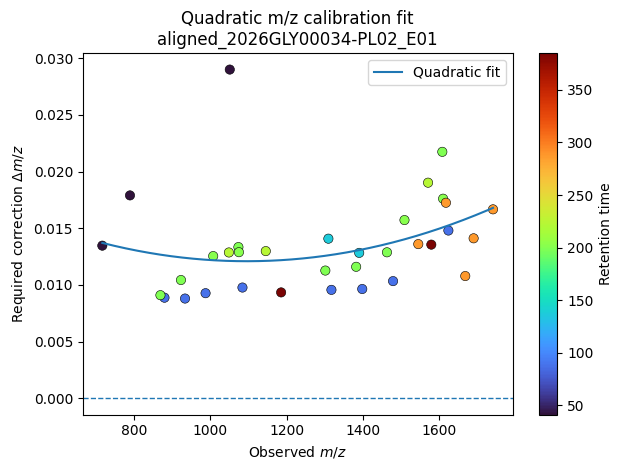

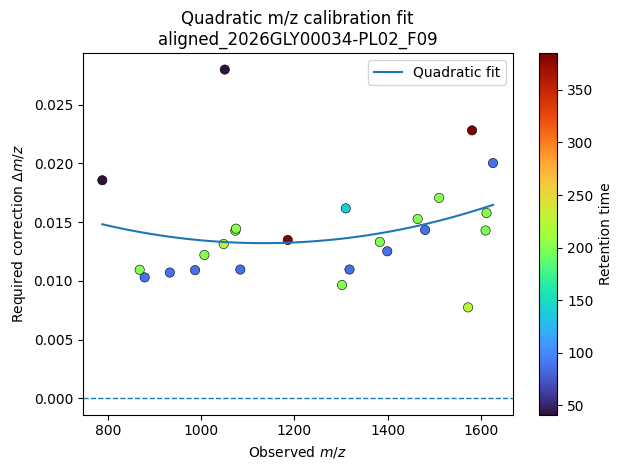

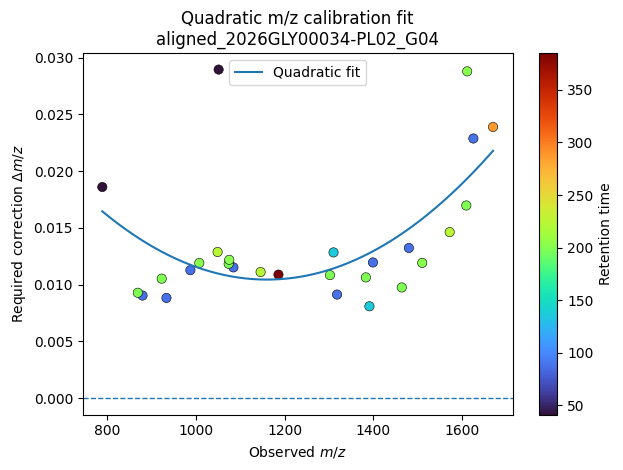

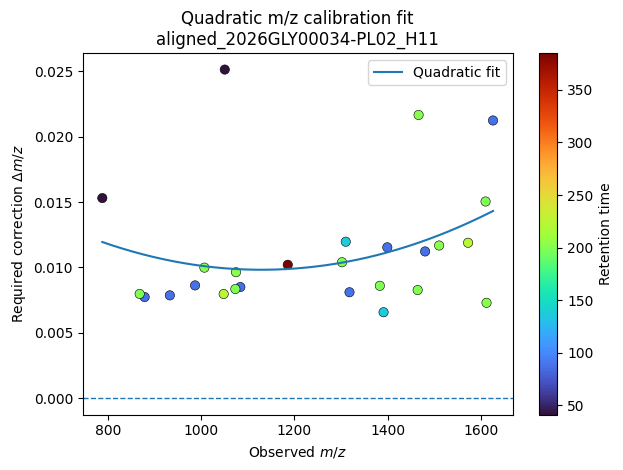

In [46]:
# Loop over calibrants of each mzXML file, then fit and visualize.
for raw_file, calibrants in calibrants_dict.items():
    fit = calibration_fit_quadratic(calibrants)
    figure = plot_calibration_fit_quadratic(calibrants, fit, raw_file)

Overall, the quadratic fits seem plausible. 
But there are some notable outliers. Especially the early eluting
calibrant seem to be outliers and cluster together.

There are also some occasional high m/z outliers.

Next we'll plot the residuals against retention time, with the points
colored by m/z.

In [47]:
def plot_quadratic_calibration_residuals(
    calibrants: list[dict],
    fit: np.ndarray,
    raw_file: str
) -> Figure:
    mz_observed = np.array(
    [
        calibrant["mz_observed"]
        for calibrant in calibrants
    ],
    dtype=float
    )

    mz_delta = np.array(
        [
            calibrant["mz_exact"] - calibrant["mz_observed"]
            for calibrant in calibrants
        ]
    )

    time = np.array(
        [
            calibrant["time"]
            for calibrant in calibrants
        ],
        dtype=float
    )

    # Apply fit to observed m/z values.
    mz_delta_predicted = np.polyval(fit, mz_observed)

    # Calculate residuals.
    residuals = mz_delta - mz_delta_predicted

    # Make figure.
    figure, axis = plt.subplots()
    scatter = axis.scatter(
        time,
        residuals,
        c=mz_observed,
        cmap="plasma",
        s=45,
        edgecolors="black",
        linewidths=0.4
    )
    axis.axhline(0, linewidth=1, linestyle="--")
    axis.set_xlabel("Retention time")
    axis.set_ylabel(r"Residual $\Delta m/z$")
    axis.set_title(f"Quadratic calibration residuals by retention time\n{raw_file}")
    colorbar = figure.colorbar(scatter, ax=axis)
    colorbar.set_label(r"Observed $m/z$")

    figure.tight_layout()

    return figure

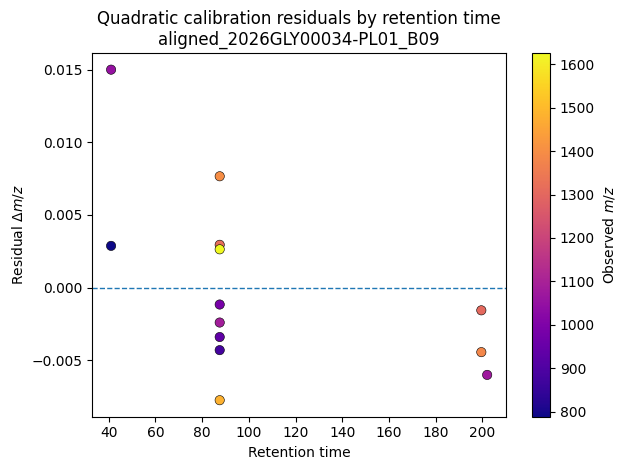

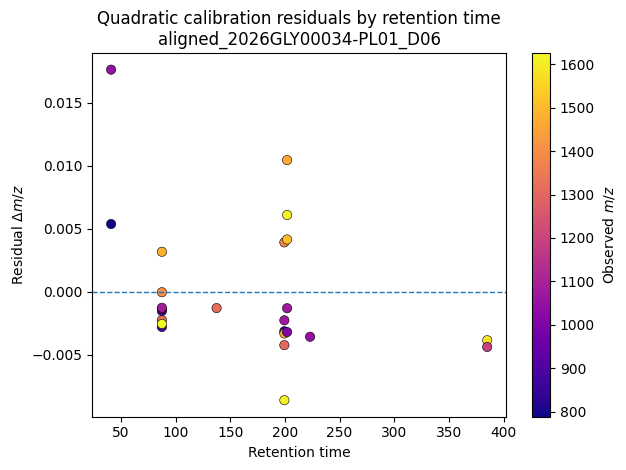

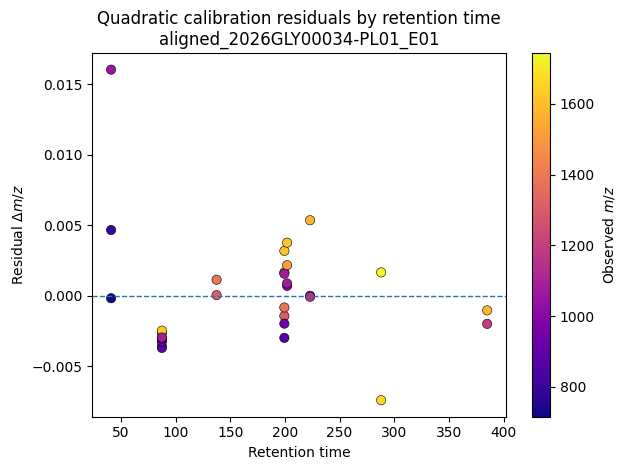

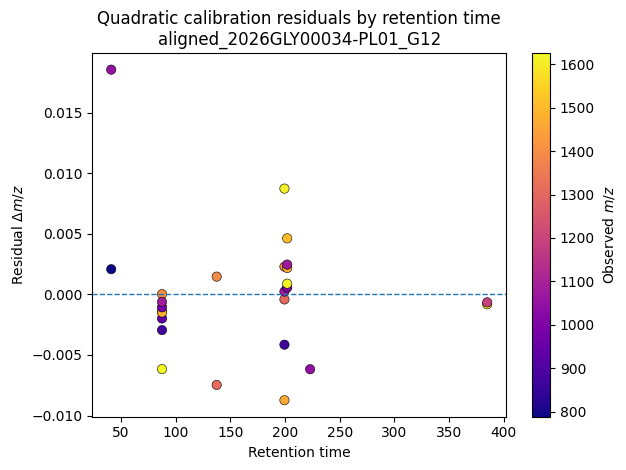

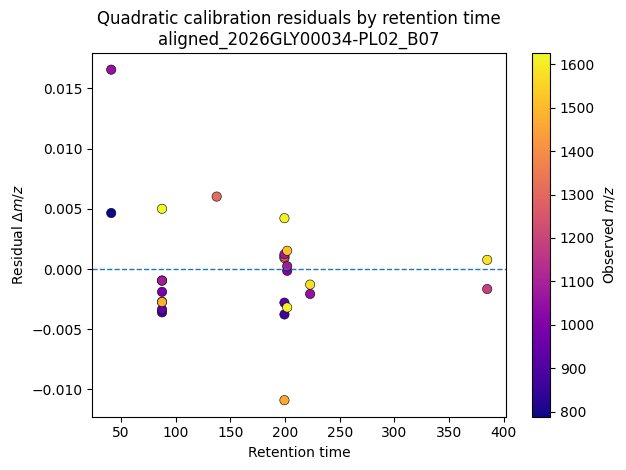

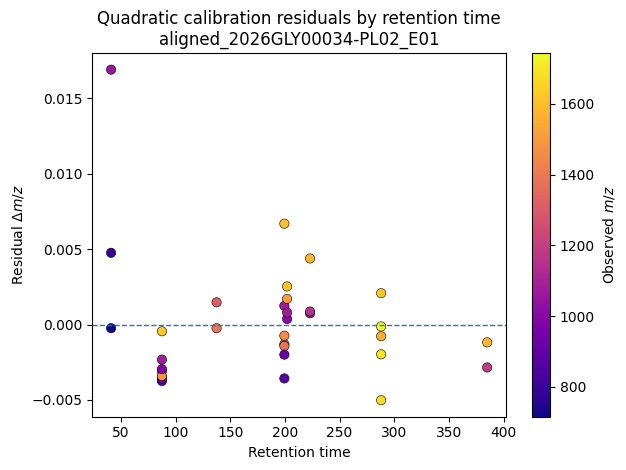

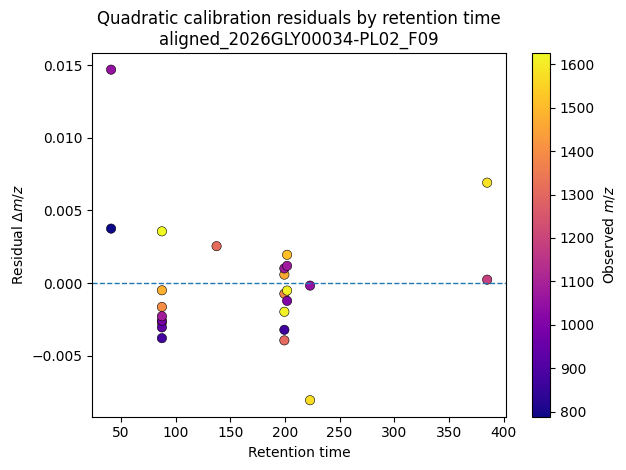

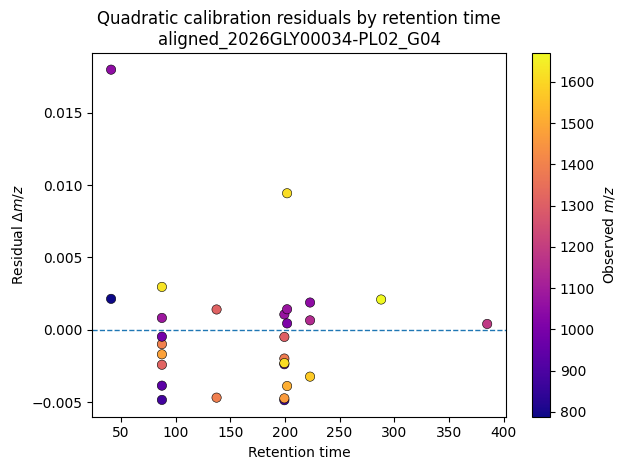

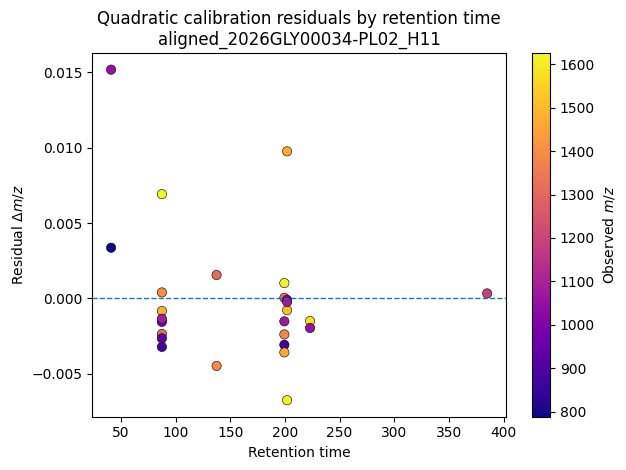

In [48]:
for raw_file, calibrants in calibrants_dict.items():
    fit = calibration_fit_quadratic(calibrants)
    figure = plot_quadratic_calibration_residuals(calibrants, fit, raw_file)

The residuals appear to not be entirely randomly distributed around 0.
Overall, they seem to be a bit higher at earlier retention times.
But there is no clear linear trend and there are clear outliers.

A sensible next step would be to add a linear time term to the model:
$$\Delta m/z = \beta_0 + \beta_1 \times m/z_\text{observed} + \beta_2 \times (m/z_\text{observed})^2 + \beta_3 \times t$$

## Fit including linear retention time term

In [49]:
def calibration_fit_time(calibrants: list[dict]) -> np.ndarray:
    """Fit a quadratic m/z plus linear time calibration model.
    
    The model predicts the required m/z correction:

        mz_exact - mz_observed

    using the model:

        mz_delta = (
            beta_0
            + beta_1 * mz_observed
            + beta_2 * mz_observed**2
            + beta_3 * time
        )
    
    Returns a NumPy array containing the fitted coefficients in the order:
    [quadratic m/z, linear m/z, time, intercept]
    """
    mz_observed = np.array(
        [
            calibrant["mz_observed"] 
            for calibrant in calibrants
        ],
        dtype=float
    )

    mz_delta = np.array(
        [
            calibrant["mz_exact"] - calibrant["mz_observed"]
            for calibrant in calibrants
        ],
        dtype=float
    )

    time = np.array(
        [
            calibrant["time"]
            for calibrant in calibrants
        ],
        dtype=float
    )

    design_matrix = np.column_stack(
        [
            mz_observed**2,
            mz_observed,
            time,
            np.ones_like(mz_observed)
        ]
    )

    fit, _, _, _ = np.linalg.lstsq(
        design_matrix,
        mz_delta,
        rcond=None
    )

    return fit

Before using above fitting function including time, it is useful to do a
regression using the `statsmodels` package which should also give p-values
for the coefficients. Looking at the p-value for time is equivalent to an 
ANOVA comparing the full model and the one without time, because they only
differ by the linear time effect.

In [50]:
import statsmodels.api as sm
from statsmodels.regression.linear_model import RegressionResultsWrapper

def calibration_fit_time_pvals(
    calibrants: list[dict]
) -> RegressionResultsWrapper:
    mz_observed = np.array(
        [
            calibrant["mz_observed"]
            for calibrant in calibrants
        ],
        dtype = float
    )

    mz_delta = np.array(
        [
            calibrant["mz_exact"] - calibrant["mz_observed"]
            for calibrant in calibrants
        ],
        dtype = float
    )

    time = np.array(
        [
            calibrant["time"]
            for calibrant in calibrants
        ],
        dtype=float
    )

    design_matrix = np.column_stack(
        [
            mz_observed,
            mz_observed**2,
            time
        ]
    )

    design_matrix = sm.add_constant(design_matrix)

    return sm.OLS(mz_delta, design_matrix).fit()

In [51]:
for _, calibrants in calibrants_dict.items():
    print(calibration_fit_time_pvals(calibrants).pvalues[3])

0.045124246660758406
0.08070057949686382
0.4453334159101733
0.520720758468149
0.20768864307366258
0.300189926930302
0.8010341173736504
0.43165771154903954
0.20140188917165225


These p-values indicate that including a linear retention time term can
sometimes improve the fit. But all this tests is whether the time effect
is different from zero, it tells nothing yet about the actual effect.

We'll compare the pre- and post-calibration mass errors of the calibrants
using both models.

In [52]:
def get_calibrant_mass_errors(
    calibrants: list[dict],
    fit_quadratic: np.ndarray,
    fit_time: np.ndarray
):
    mz_observed = np.array(
    [
        calibrant["mz_observed"]
        for calibrant in calibrants
    ],
    dtype = float
    )

    mz_exact = np.array(
        [
            calibrant["mz_exact"]
            for calibrant in calibrants
        ],
        dtype = float
    )

    time = np.array(
        [
            calibrant["time"]
            for calibrant in calibrants
        ],
        dtype=float
    )

    # Correction predicted by quadratic m/z-only model.
    correction_quadratic = np.polyval(
        fit_quadratic, mz_observed
    )

    # Correction predicted by the model including time.
    (
        quadratic_coeff,
        linear_coeff,
        time_coeff,
        intercept
    ) = fit_time

    correction_time = (
        quadratic_coeff * mz_observed**2
        + linear_coeff * mz_observed
        + time_coeff * time
        + intercept
    )

    # Calculate calibrated m/z values
    mz_calibrated_quadratic = mz_observed + correction_quadratic
    mz_calibrated_time = mz_observed + correction_time

    # Calculate pre- and post-calibration mass errors
    mass_error_before_ppm = (mz_observed - mz_exact) / mz_exact * 1e6
    mass_error_quadratic_ppm = (mz_calibrated_quadratic - mz_exact) / mz_exact * 1e6
    mass_error_time_ppm = (mz_calibrated_time - mz_exact) / mz_exact * 1e6

    return pd.DataFrame(
        {
            "mz_exact": mz_exact,
            "mz_observed": mz_observed,
            "time": time,
            "mz_calibrated_quadratic": mz_calibrated_quadratic,
            "mz_calibrated_time": mz_calibrated_time,
            "mass_error_before_ppm": mass_error_before_ppm,
            "mass_error_quadratic_ppm": mass_error_quadratic_ppm,
            "mass_error_time_ppm": mass_error_time_ppm
        }
    )

In [57]:
def plot_calibrant_mass_error_comparison(
    mass_errors: pd.DataFrame,
    raw_file: str
) -> Figure:
    plot_data = mass_errors[
        [
            "mass_error_before_ppm",
            "mass_error_quadratic_ppm",
            "mass_error_time_ppm"
        ]
    ].copy()

    plot_data.columns = [
        "Before",
        "Quadratic",
        "Quadratic + time"
    ]

    figure, axis = plt.subplots()

    for _, row in plot_data.iterrows():
        axis.plot(
            plot_data.columns,
            row,
            marker="o",
            alpha=0.35
        )

    axis.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    axis.set_ylabel("Mass error (ppm)")

    axis.set_title(f"Pre- and post-calibration mass errors\n{raw_file}")

    figure.tight_layout()

    return figure

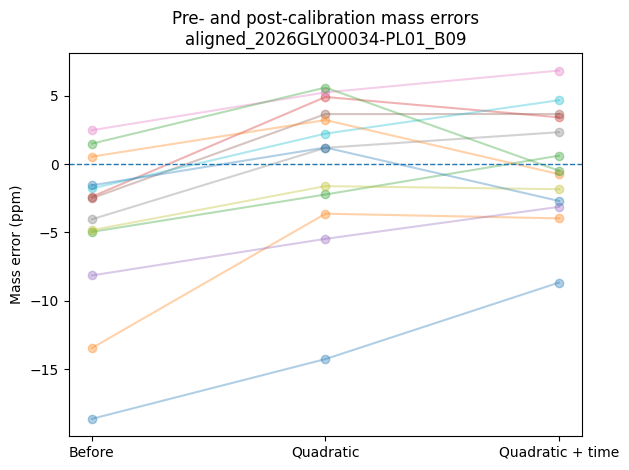

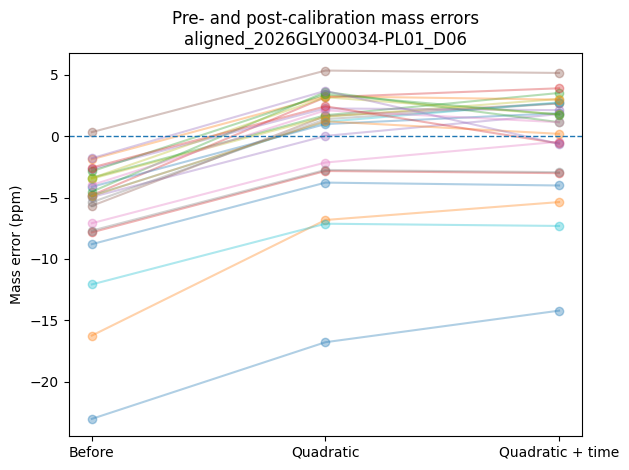

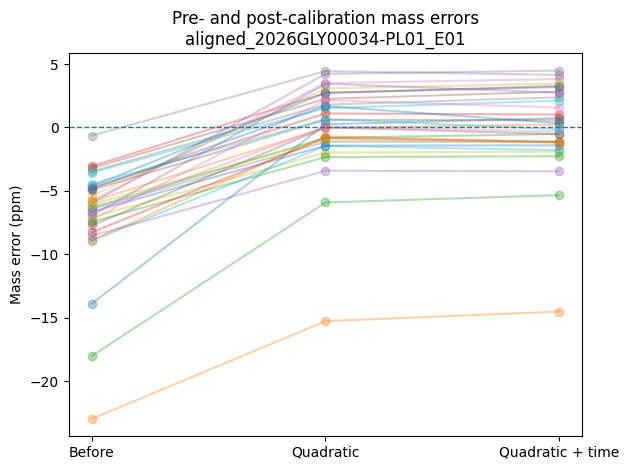

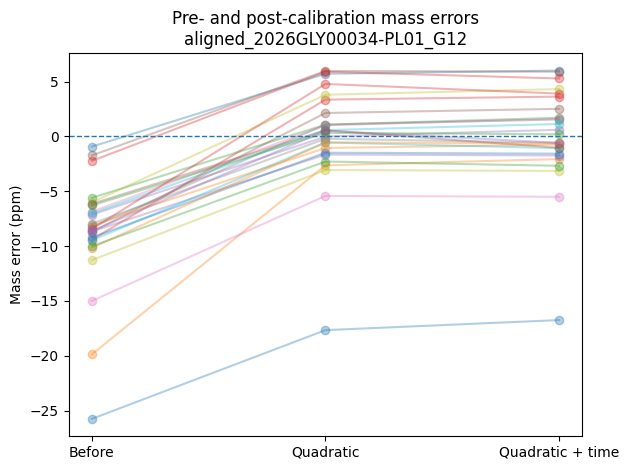

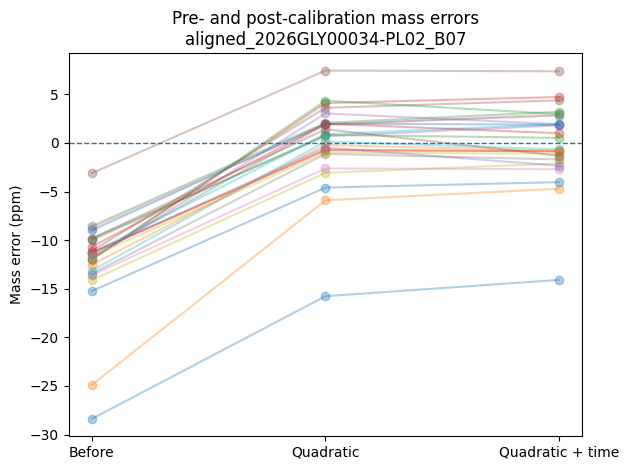

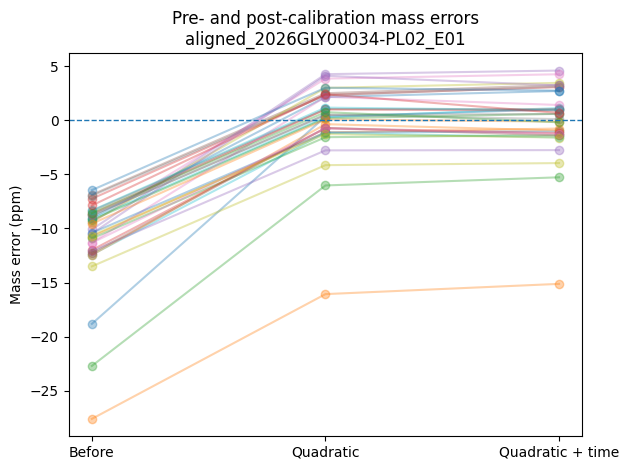

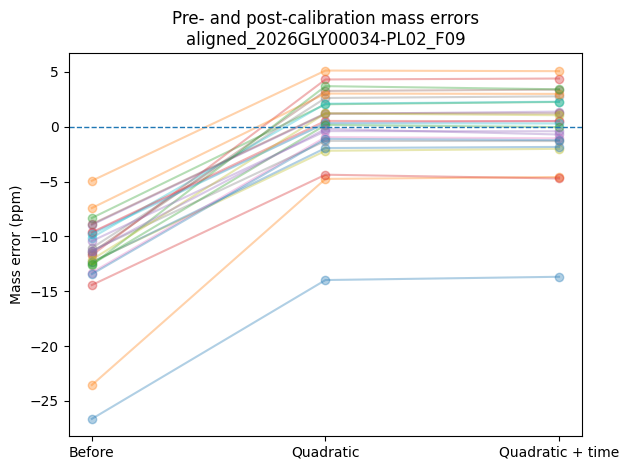

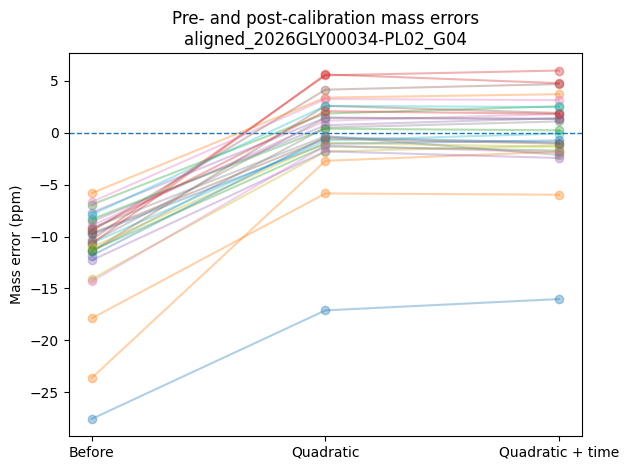

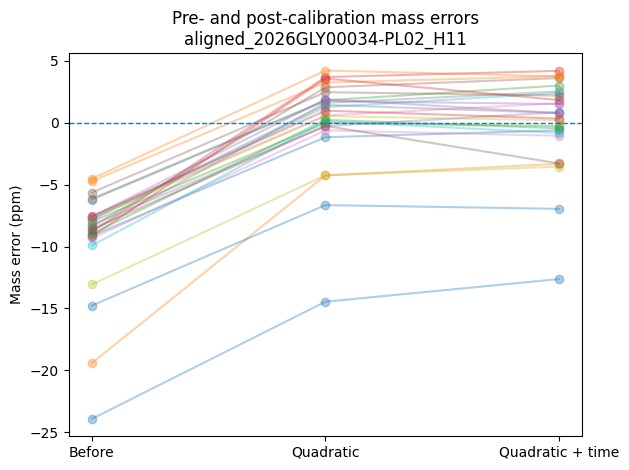

In [58]:
for raw_file, calibrants in calibrants_dict.items():
    fit_quadratic = calibration_fit_quadratic(calibrants)
    fit_time = calibration_fit_time(calibrants)

    mass_errors = get_calibrant_mass_errors(
        calibrants, fit_quadratic, fit_time
    )

    figure = plot_calibrant_mass_error_comparison(
        mass_errors, raw_file
    )

Based on the figures above, the quadratic m/z calibration clearly reduces
the mass errors. Including time seems to have a minimal impact. Sometimes
it improves the mass erros somewhat, and sometimes it makes them a bit worse.
This suggests that a quadratic fit without retention time is sufficient.

What we should still do is compare the post-calibration mass erros from this
new method with the older method where calibration is performed per retention
time range.